Models can request to call tools that perform tasks such as fetching data from a database, searching the web, or running code

In [6]:
import groq
import langchain
import langchain_groq

print("groq:", groq.__version__)
print("langchain:", langchain.__version__)
print("langchain_groq:", langchain_groq.__version__)

groq: 0.37.1
langchain: 1.3.4
langchain_groq: 1.1.2


In [7]:
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

load_dotenv()

model = init_chat_model("groq:qwen/qwen3-32b")

response = model.invoke("Why do parrots speak?")
print(response.content)

<think>
Okay, so I need to figure out why parrots speak. Let me start by recalling what I know about parrots. They're known for mimicking sounds, right? But why do they do that? Maybe it's related to their survival or social behavior.

First, I remember that parrots are highly social animals. They live in flocks, so communication is important. Maybe they use sounds to interact with each other. But why would they mimic human speech? Is it just because they're exposed to humans, or is there a deeper reason?

I think about other birds that mimic sounds, like lyrebirds or starlings. They mimic to blend in with their environment or to impress others. Parrots might do something similar. But humans aren't part of their natural environment, so why do they pick up human speech?

Maybe it's a form of social bonding. If a parrot is in a human home, it might mimic the owner's voice to communicate or get attention. They might learn that saying certain words gets a reaction, like food or affection. 

In [8]:
import os
from langchain.chat_models import init_chat_model

os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:qwen/qwen3-32b")
response = model.invoke("why do parrots speak?")
response.content

'<think>\nOkay, so the user is asking, "Why do parrots speak?" Let me start by recalling what I know about parrots and their ability to mimic human speech. Parrots are part of the Psittaciformes order, and they\'re known for their vocal mimicry. But why exactly do they do that?\n\nFirst, I should consider their natural behavior. In the wild, parrots don\'t just imitate humans; they mimic other birds and environmental sounds. So maybe their ability isn\'t just for humans but is a broader adaptation. Communication is a key aspect. In the wild, parrots use vocalizations to communicate with their flock, signal danger, or attract mates. So perhaps in captivity, when they\'re around humans, they transfer this mimicry to human speech.\n\nAnother angle is learning. Parrots are highly intelligent birds with complex brains. They have a part of the brain called the nidopallium, which is similar to the mammalian neocortex, responsible for higher cognitive functions. This might enable them to proce

In [18]:
from langchain.tools import tool

@tool
def get_weather(location:str)->str:
    """Get the weather at a location"""
    respone = model.invoke(f"what is the current weather in {location}")
    return response.content


model_with_tool = model.bind_tools([get_weather])
 
response = model_with_tool.invoke("What is the weather in Tokyo?")
response.tool_calls

[{'name': 'get_weather',
  'args': {'location': 'Tokyo'},
  'id': '383hhzcv3',
  'type': 'tool_call'}]

tool execution

In [19]:
#Step 1: Model generates tool calls
messages = [{'role':'user','content':'What is the weather in boston?'}]
ai_msg = model_with_tool.invoke(messages)
messages.append(ai_msg)

#Step 1: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
    #execute tools with generated arguments
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

#Step 3: Pass the result back to model for final response
final_response = model_with_tool.invoke(messages)
print(final_response.text)

The weather in Boston is clear with a temperature of 68°F. It's a great day to be outdoors!


In [20]:
#Step 1: Model generates tool calls
messages = [{'role':'user','content':'who is salman khan?'}]
ai_msg = model_with_tool.invoke(messages)
messages.append(ai_msg)

#Step 1: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
    #execute tools with generated arguments
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

#Step 3: Pass the result back to model for final response
final_response = model_with_tool.invoke(messages)
print(final_response.text)

Okay! Let me know if you need anything else. 😊


In [11]:
messages

[{'role': 'user', 'content': 'What is the weather in boston?'},
 AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the weather in Boston. Let me check the tools available. There\'s a function called get_weather that takes a location parameter. Since the user specified Boston, I need to call this function with "Boston" as the location. I\'ll make sure to format the tool call correctly within the XML tags as instructed.\n', 'tool_calls': [{'id': 'byqaw0mn3', 'function': {'arguments': '{"location":"Boston"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 154, 'total_tokens': 247, 'completion_time': 0.141365424, 'completion_tokens_details': {'reasoning_tokens': 69}, 'prompt_time': 0.006946098, 'prompt_tokens_details': None, 'queue_time': 0.438759404, 'total_time': 0.148311522}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_dema

another way of making tool

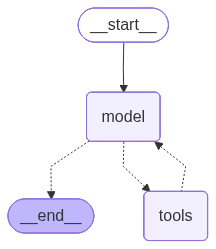

In [12]:
from langchain.agents import create_agent

def get_weather(city:str)->str:
    """get weather of the city"""
    return f"the weather in {city} is summer"

agent = create_agent(
    model = 'groq:qwen/qwen3-32b',
    tools = [get_weather],
    system_prompt="You are a helpful assistant"
)

agent

In [16]:
from langchain.agents import create_agent
import os

# Set your Groq API Key, ALREADY SET


def get_weather(city: str) -> str:
    """Get the current weather for a city."""

    weather_data = {
        "mumbai": "Temperature: 31°C, Condition: Partly Cloudy",
        "delhi": "Temperature: 38°C, Condition: Sunny",
        "bangalore": "Temperature: 26°C, Condition: Light Rain",
        "kolkata": "Temperature: 33°C, Condition: Humid",
        "chennai": "Temperature: 30°C, Condition: Moderate Rain"
    }

    return weather_data.get(
        city.lower(),
        f"Weather data for '{city}' is unavailable."
    )


agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[get_weather],
    system_prompt="""
You are a helpful AI assistant.

- Answer general knowledge questions using your own knowledge.
- Only use the weather tool when the user asks about weather.
- If a question does not require a tool, answer it directly.
"""
)

response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Who is salman khan?"
            }
        ]
    }
)

print(response["messages"][-1].content)

Salman Khan is a renowned Indian actor, producer, and television personality who has been a prominent figure in the Bollywood film industry since the 1980s. Known for his versatile roles and charismatic screen presence, he has starred in numerous successful films such as *Maine Pyar Ki*, *Bajrangi Bhaijaan*, and *Sultan*. Beyond acting, he is also recognized for his work in philanthropy through the Being Human Foundation, which focuses on disaster relief and social welfare.
